In [1]:
import pandas as pd
import numpy as np
import os
import glob
import importlib
import config
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

importlib.reload(config)

pd.options.display.float_format = '{:,.4f}'.format
pd.set_option('display.max_columns', None)

In [2]:
def calculate_metrics(group):
    # Only calculate correlation if we have enough data (at least 3 days)
    
    if len(group) < 3:
        return pd.Series({
            'IHSG_Corr': 0, 
            'Foreign_Corr': 0, 
            'Avg_Volume': group['X2_Volume'].mean(), 
            'Price_Volatility': 0
        })
    
    return pd.Series({
        'IHSG_Corr': group['Y_Price_Return'].corr(group['X3_IHSG_Return']),
        'Foreign_Corr': group['Y_Price_Return'].corr(group['X1_Foreign_Intensity']),
        'Avg_Volume': group['X2_Volume'].mean(),
        'Price_Volatility': group['Y_Price_Return'].std()
    })

In [3]:
# 1. Load Summary Trading Stocks and List Stocks (in masked folder)

input_data = os.path.join(config.CLEAN_MASTER_DATA_PATH, "clean_master_data.csv")

try:
    df_data = pd.read_csv(input_data)
    df_data = df_data.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
    
    print(f"Successfully read: {os.path.basename(input_data)}")
    print(df_data.head())

except Exception as e:
    print(f"An error occurred: {e}")

Successfully read: clean_master_data.csv
   No Kode Saham  Sebelumnya  Open Price Tanggal Perdagangan Terakhir  \
0   2  Saham_001  7,575.0000        7575                   2025-12-01   
1   5  Saham_004  2,920.0000        2920                   2025-12-01   
2   6  Saham_005    418.0000         418                   2025-12-01   
3   8  Saham_006    139.0000         140                   2025-12-01   
4  10  Saham_007 15,350.0000       15500                   2025-12-01   

   First Trade  Tertinggi  Terendah   Penutupan  Selisih          Volume  \
0         7575       7650      7525  7,650.0000       75    755,600.0000   
1         2910       2930      2900  2,910.0000      -10    633,500.0000   
2          420        422       416    416.0000       -2 69,207,600.0000   
3          140        141       130    133.0000       -6  9,585,600.0000   
4        15500      15600     15375 15,375.0000       25     22,100.0000   

         Nilai  Frekuensi  Index Individual  Offer  Offer Volum

In [4]:
duplicates = df_data.duplicated(subset=['Kode Saham', 'Tanggal Perdagangan Terakhir']).sum()

if duplicates > 0:
    print(f"⚠️ Warning: You have {duplicates} duplicate rows! We need to fix the merge.")
else:
    print("✅ No duplicates found. Your ticker similarity is likely just different companies.")

⚠️ Warning: You have 265 duplicate rows! We need to fix the merge.


In [5]:
print(f"Before cleaning: {df_data.shape}")

df_data = df_data.drop_duplicates(
    subset=['Kode Saham', 'Tanggal Perdagangan Terakhir'], 
    keep='first'
).copy()

print(f"After cleaning: {df_data.shape}")

Before cleaning: (14882, 33)
After cleaning: (14617, 33)


In [6]:
# Select your target metrics for the final check
metrics = ['Y_Price_Return', 'X1_Foreign_Intensity', 'X2_Volume', 'X3_IHSG_Return']
print(df_data[metrics].describe())

       Y_Price_Return  X1_Foreign_Intensity          X2_Volume  X3_IHSG_Return
count     14,617.0000           14,617.0000        14,617.0000     14,617.0000
mean           0.0015               -0.0111    44,895,980.2285         -0.0006
std            0.0473                0.1919   212,194,076.2592          0.0146
min           -0.1500               -0.9950             0.0000         -0.0735
25%           -0.0146               -0.0829       278,300.0000         -0.0053
50%            0.0000                0.0000     3,406,700.0000          0.0003
75%            0.0110                0.0625    20,302,000.0000          0.0072
max            0.3497                1.0000 5,863,700,700.0000          0.0252


hmmm, it is concluded that:
1. max 

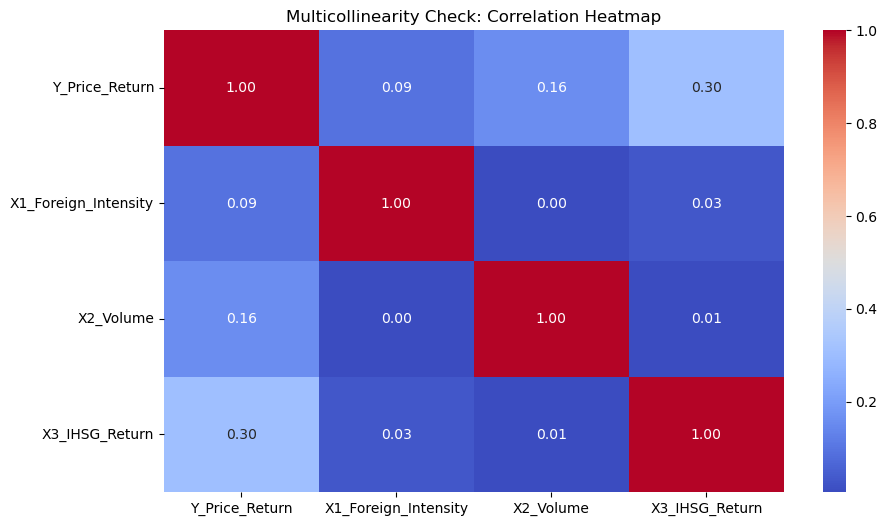

In [7]:
corr_matrix = df_data[['Y_Price_Return', 'X1_Foreign_Intensity', 'X2_Volume', 'X3_IHSG_Return']].corr()

# 2. Plot the Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Multicollinearity Check: Correlation Heatmap")
plt.show()

# All of the collinearity for each variable are below 0.5 it means all of the variables are individual

In [8]:
# 3. Check the Variance Inflation Factor (VIF)
X_vif = df_data[['X1_Foreign_Intensity', 'X2_Volume', 'X3_IHSG_Return']].dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("--- Multicollinearity Validation (Phase 2.3) ---")
print(vif_data)

--- Multicollinearity Validation (Phase 2.3) ---
                feature    VIF
0  X1_Foreign_Intensity 1.0010
1             X2_Volume 1.0001
2        X3_IHSG_Return 1.0010


VIF < 5: Perfect independence.
VIF > 10: The variables are "leaking" into each other, and the clusters will be "blurry."

# It concludes that all of the variables are perfect independence

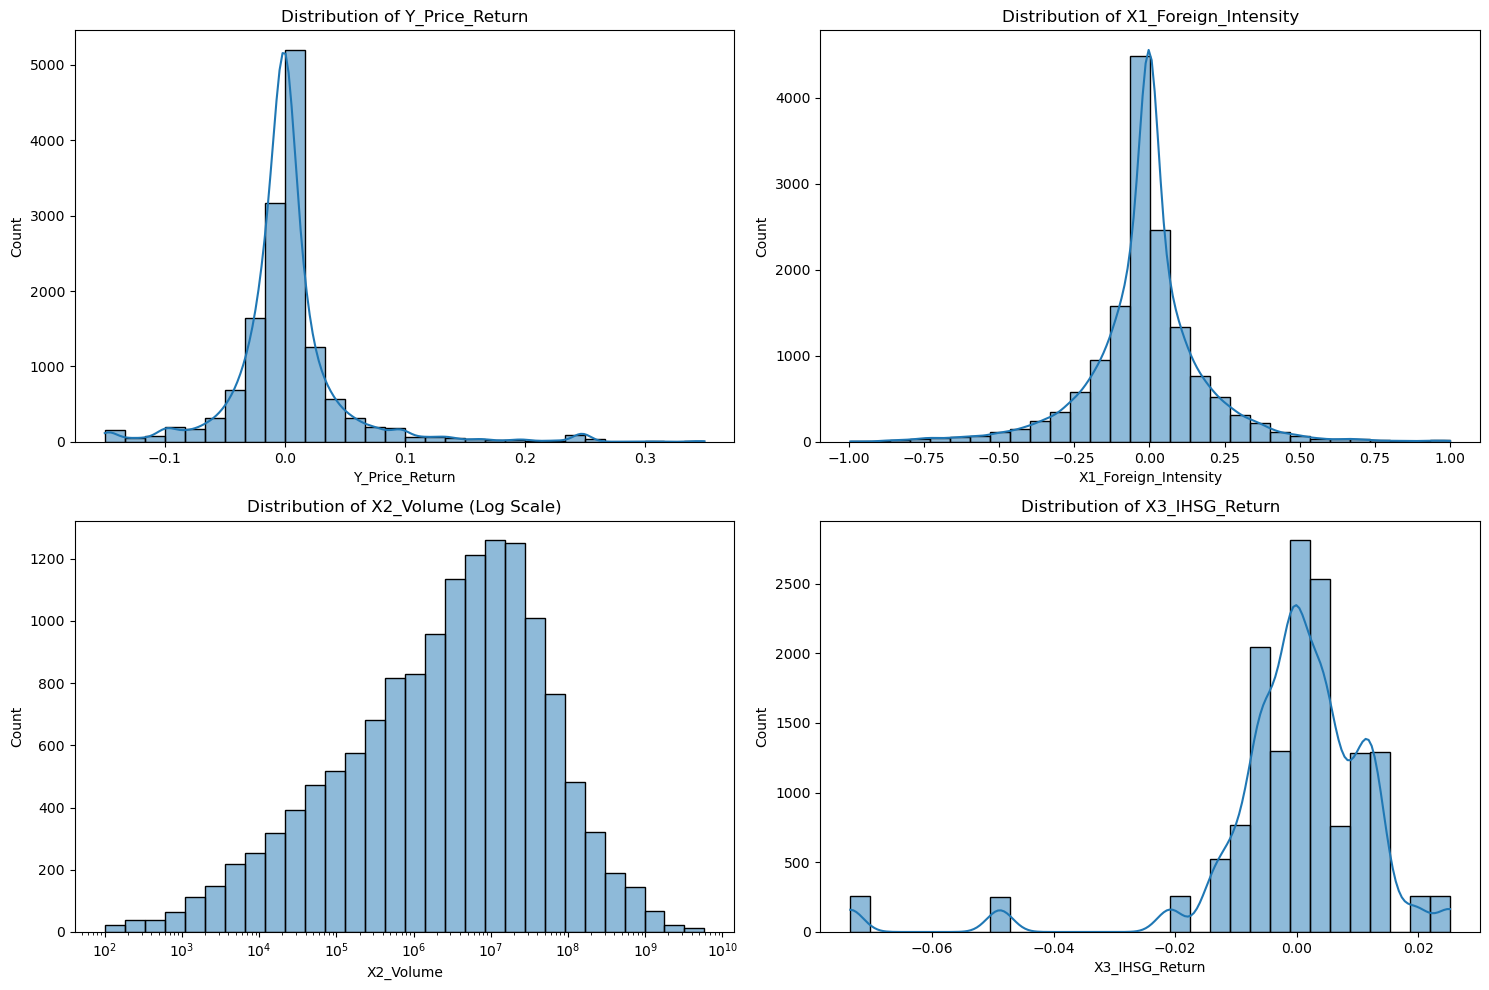

In [9]:
# 4. DISTRIBUTION CHECK (Histograms)
# Purpose: To see if your data is skewed or follows a normal distribution.
plt.figure(figsize=(15, 10))
for i, col in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    # Using log scale for Volume (X2) because the numbers are very large (billions)
    if col == 'X2_Volume':
        sns.histplot(df_data[col], kde=True, bins=30, log_scale=True)
        plt.title(f'Distribution of {col} (Log Scale)')
    else:
        sns.histplot(df_data[col], kde=True, bins=30)
        plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

1. Y (Price Return): The "Leaning Dragon"
What you see: A massive, sharp spike at 0.0 and a "tail" that stretches further to the right than to the left.
The Interpretation: Most of the time, the Mid-Cap stocks are "resting" (0% change). However, the right-side skew (Positive Skewness) is a beautiful sight for a Growth Hunter. it proves that when these stocks move, they tend to explode upward (ARA) more often than they collapse to the floor.

2. X1 (Foreign Intensity): The "Zero or Hero" Signal
What you see: A huge spike at 0.0, but smaller "bumps" near 1.0 and -1.0.
The Interpretation: This shows that foreigners are "Passive" in the Mid-Cap stocks most of the time. But when the bumps appear at the edges, it means institutional players are taking over 100% of the daily volume. This is your "Lead Indicator" for a Regime Shift.

3. X2 (Volume): The "Log Scale" Bell
What you see: Since you used log_scale=True, the data looks like a classic bell curve (Normal Distribution).
The Interpretation: Without the Log Scale, this chart would be impossible to read because Indonesian volume ranges from "Thin" to "Billions." By using the log, you've "tamed" the data. It shows that the Mid-Cap stocks has a healthy, consistent level of liquidity that the model can actually work with.

4. X3 (IHSG Return): The "Center of Gravity"
What you see: A more balanced, centered distribution around 0.0.
The Interpretation: The IHSG is the "Average" of everything. It is much more stable than your individual stocks. Because Y (the stocks) is much "wider" and "spikier" than X3 (IHSG), it confirms that you are playing in a high-volatility arena where "Alpha Stocks" (outperforming the market) is possible.

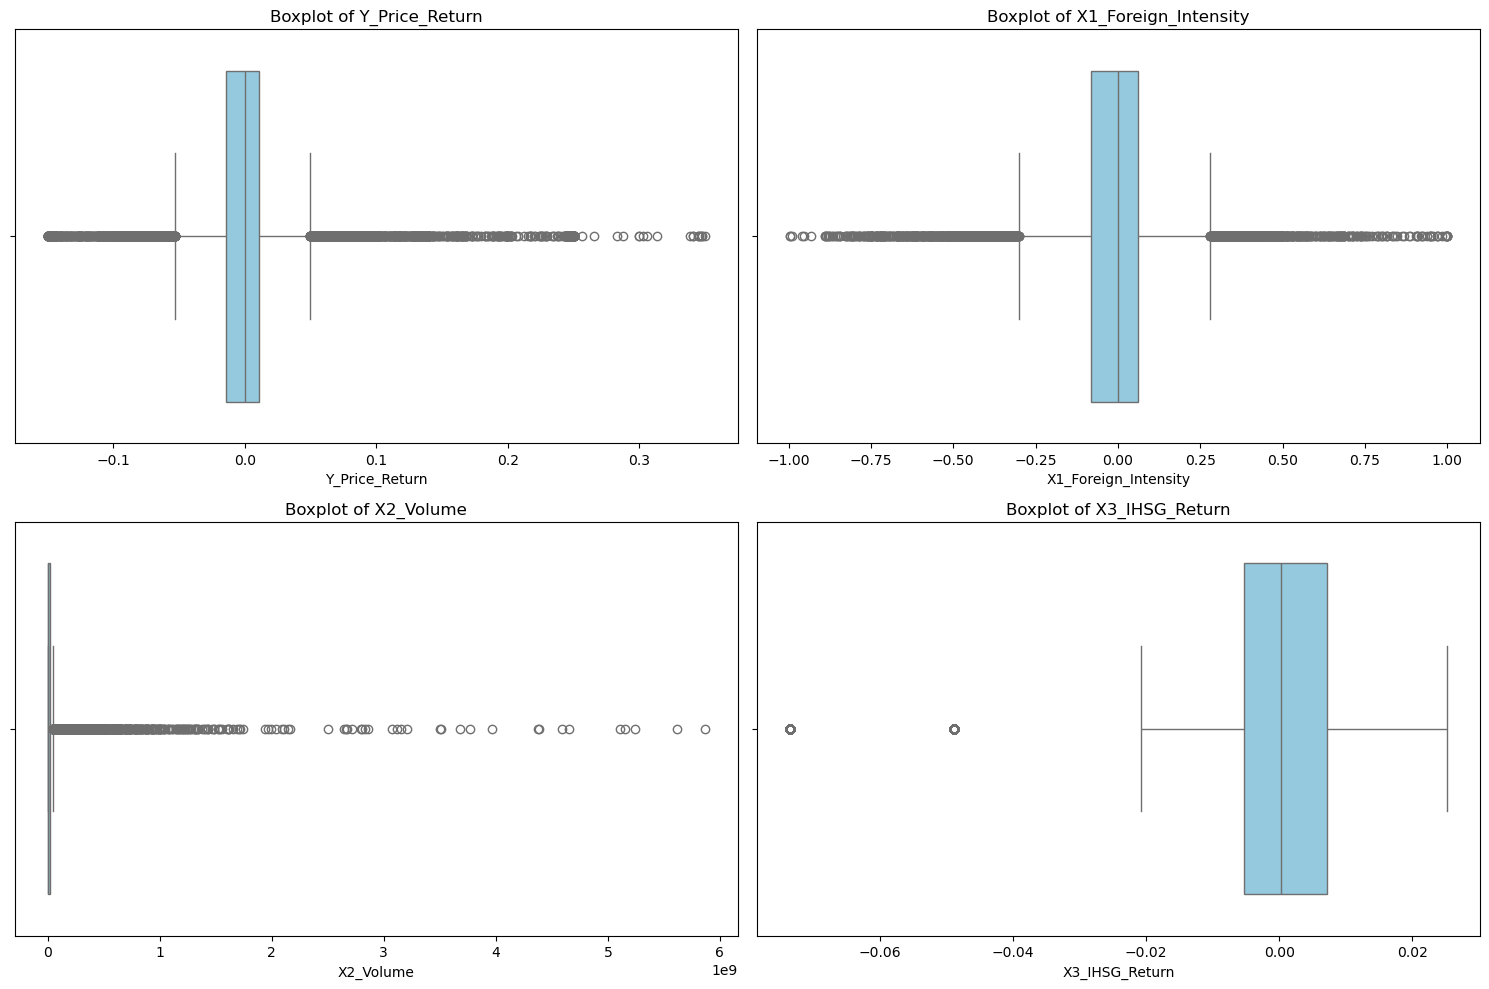

In [10]:
# 5. OUTLIER HUNT (Boxplots)
# Purpose: To identify "ARA" (limit up) or "ARB" (limit down) stocks.
plt.figure(figsize=(15, 10))
for i, col in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df_data[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

These boxplots are essentially the "Stress Test" results for the portfolio. 
In a boxplot, the "box" represents where the middle 50% of the data lives, while the individual dots are the outliers—the moments where the market went wild.

1. Boxplot of Y (Price Return): The "Limit Up/Down" Hunter
- The Box: It is extremely narrow and centered almost exactly at 0.0. This confirms that on most days, mid-cap stocks are very stable or even "dead."
- The Outliers: Look at those dots stretching up to +0.35 and down to -0.20. These are the ARA (Auto Reject Atas) and ARB (Auto Reject Bawah) events.
- Strategic Insight: The fact that the positive outliers (up to 35%) are more frequent and reach higher than the negative ones is a great sign for a "Growth Hunter." It shows the upside potential is mathematically larger than the downside risk in the current dataset.
  
2. Boxplot of X1 (Foreign Intensity): The "Silent Whale" Detector
- The Box: Again, very thin around 0.0. This means most trades are domestic-driven.
- The Outliers: The dots reaching +1.0 and -1.0 are critical. These represent days where a single foreign institution likely took over the entire ticker's volume.
- Strategic Insight: When the dot stays at +1.0 in X1, that is the stocks waking up. Because these are outliers, they represent High-Conviction moves by big money.

3. Boxplot of X2 (Volume): The "Liquidity Spike"
- The Box: The box is shifted toward the left, with a very long trail of dots to the right.
- The Outliers: These massive volume spikes (the dots far to the right) are the footprints of institutional entry.
- Strategic Insight: A "Coiling Spring" stock is one that has a dot in the Volume boxplot but still has its Y (Price) inside the main box. It means someone is buying big, but the price hasn't exploded yet.

4. Boxplot of X3 (IHSG Return): The "Market Pulse"
- The Box: This box is slightly wider than the Y box, but the outliers are much closer to the center (mostly between -0.02 and +0.02).
- Strategic Insight: This proves the IHSG is much less volatile than the individual stocks. The strategy is built to survive the small swings in this box while waiting for the "ARA" dots in the Y box.

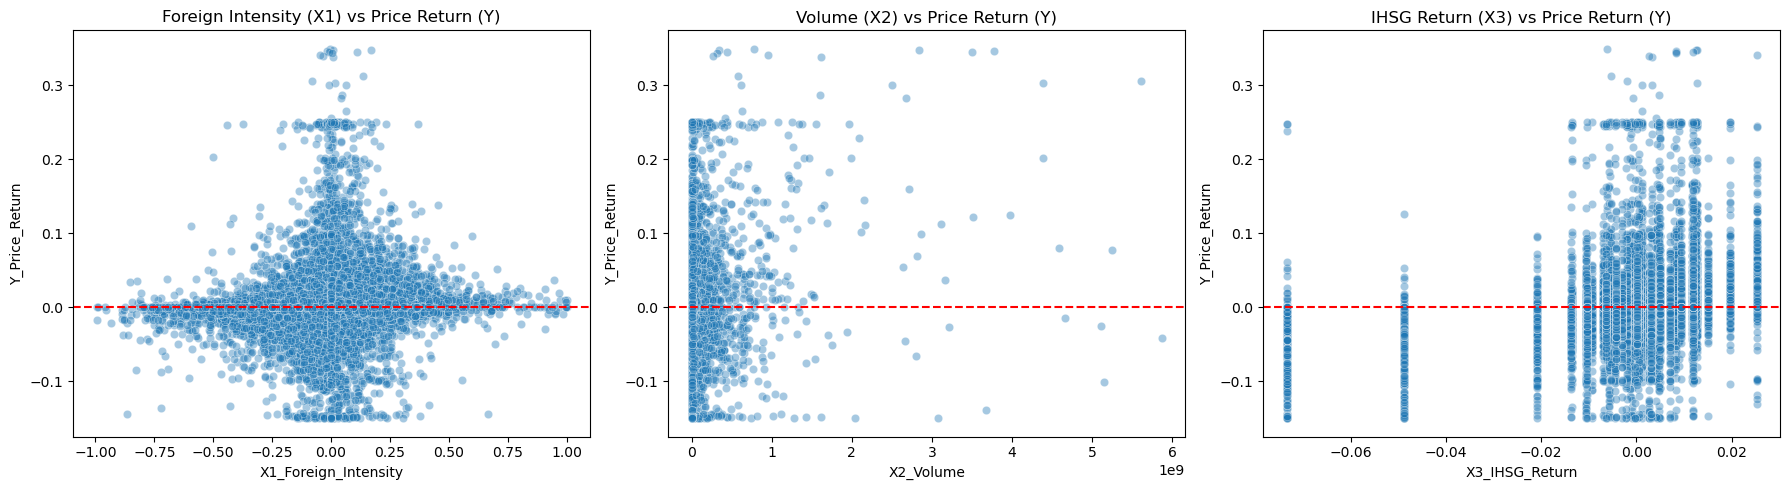

In [11]:
# 6. RELATIONSHIP MAPPING (Scatter Plots)
# Purpose: To see if Foreign Intensity (X1) or Volume (X2) actually leads to Price Growth (Y).
plt.figure(figsize=(18, 5))

# X1 vs Y
plt.subplot(1, 3, 1)
sns.scatterplot(data=df_data, x='X1_Foreign_Intensity', y='Y_Price_Return', alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title('Foreign Intensity (X1) vs Price Return (Y)')

# X2 vs Y
plt.subplot(1, 3, 2)
sns.scatterplot(data=df_data, x='X2_Volume', y='Y_Price_Return', alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title('Volume (X2) vs Price Return (Y)')

# X3 vs Y
plt.subplot(1, 3, 3)
sns.scatterplot(data=df_data, x='X3_IHSG_Return', y='Y_Price_Return', alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title('IHSG Return (X3) vs Price Return (Y)')

plt.tight_layout()
plt.show()

These scatter plots are the most critical part of the Phase 2 because they reveal the "cause and effect" in the data. While your histograms showed you what happened, these show you why it happened.

1. Foreign Intensity (X1) vs. Price Return (Y)
The "Silent Accumulation" Zone: Notice the thick horizontal band of dots sitting exactly on the red dashed line (Y=0) while stretching across the X1 axis. This is the "Value Hunter" goldmine. It represents days where foreigners were aggressively buying (X1>0.5) or selling, but the price didn't budge.

The Breakouts: The dots floating high above the red line are the "Dragons." When X1 is high and Y is high, the "Whale" has finished accumulating and the markup has begun.

Strategic Insight: We are looking for stocks that move from that horizontal Y=0 line into the top-right quadrant.

3. Volume (X2) vs. Price Return (Y)
The "Volatility Funnel": Most of the extreme price returns (the dots high above or far below the red line) occur at low to moderate volumes. As volume increases to the far right, the price returns actually tend to cluster closer to the red line.

The Interpretation: Huge volume doesn't always mean a huge price jump; often, massive volume means "Distribution" (big players fighting each other), which keeps the price stable.

Strategic Insight: The "Growth" targets are often found in the middle of the volume scale—enough liquidity to move, but not so much that the price becomes "heavy."

4. IHSG Return (X3) vs. Price Return (Y)
The "Systemic Cloud": Out of the three plots, this one shows the clearest diagonal trend (a slight upward slope). This represents the 0.30 correlation we found earlier.

The Idiosyncratic Stocks: Notice the wide vertical spread of dots when the IHSG (X3) is at 0. These are stocks that are exploding (up to 30%+) even when the market is doing absolutely nothing.

Strategic Insight: These vertical "spikes" are the Idiosyncratic Stocks. They prove the thesis that you don't need a bull market to find growth; we just need the right stock.

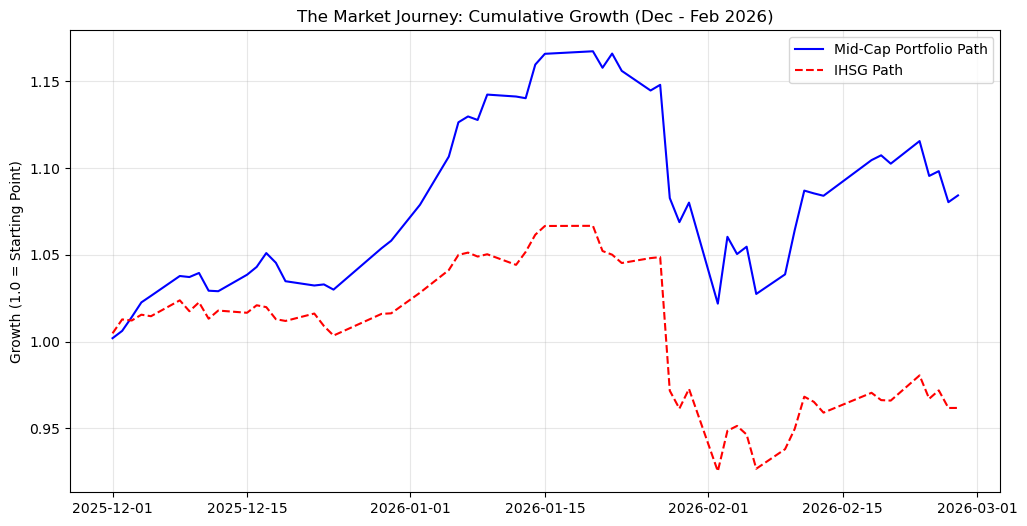

In [12]:
# 7. TIME-SERIES SCAN (Market Trend)
# Purpose: To see if the IHSG has stabilized and how your mid-cap returns compare.
# Ensure the date column is in datetime format
df_data['Tanggal Perdagangan Terakhir'] = pd.to_datetime(df_data['Tanggal Perdagangan Terakhir'])
ts_data = df_data.groupby('Tanggal Perdagangan Terakhir')[['Y_Price_Return', 'X3_IHSG_Return']].mean()

# Calculate Cumulative Returns (Starting from 1.0 or 100%)
ts_data_cum = (1 + ts_data).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(ts_data_cum.index, ts_data_cum['Y_Price_Return'], label='Mid-Cap Portfolio Path', color='blue')
plt.plot(ts_data_cum.index, ts_data_cum['X3_IHSG_Return'], label='IHSG Path', color='red', linestyle='--')
plt.title('The Market Journey: Cumulative Growth (Dec - Feb 2026)')
plt.ylabel('Growth (1.0 = Starting Point)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
# 7. Market Alignment Audit
# Calculate the overall Beta/Correlation of the data

market_corr = df_data['Y_Price_Return'].corr(df_data['X3_IHSG_Return'])
print(f"\nOverall Market Alignment: {market_corr:.2f}")
if market_corr > 0.5:
    print("Status: The stocks is currently SYSTEMIC (Following IHSG).")
else:
    print("Status: The stocks is currently IDIOSYNCRATIC (Individual moves dominate).")


Overall Market Alignment: 0.30
Status: The stocks is currently IDIOSYNCRATIC (Individual moves dominate).


In [14]:
# 8. Calculate Ticker-level Correlations
# This groups by Ticker to see how each stock behaves individually

ticker_audit = df_data.groupby('Kode Saham').apply(
    calculate_metrics, 
    include_groups=False # <--- This is the critical edit
).reset_index()

alpha_tickers = ticker_audit[
    (ticker_audit['Foreign_Corr'] > 0.4) & 
    (ticker_audit['IHSG_Corr'] < 0.2)
]

latest_date = df_data['Tanggal Perdagangan Terakhir'].max()
five_days_ago = latest_date - pd.Timedelta(days=5)

recent_data = df_data[df_data['Tanggal Perdagangan Terakhir'] >= five_days_ago]
coiling_springs = recent_data.groupby('Kode Saham').filter(
    lambda x: (x['X2_Volume'].mean() > df_data['X2_Volume'].median()) and 
              (abs(x['Y_Price_Return'].mean()) < 0.01)
)['Kode Saham'].unique()

print(f"--- Phase 2 Strategic Audit Results ---")
print(f"Alpha Tickers Found: {len(alpha_tickers)} stocks")
print(f"Coiling Springs (Potential Breakouts): {len(coiling_springs)} stocks")

print("--- [ALPHA TICKERS] ---")
print("High Foreign Correlation + Low IHSG Correlation")
print(alpha_tickers)

--- Phase 2 Strategic Audit Results ---
Alpha Tickers Found: 10 stocks
Coiling Springs (Potential Breakouts): 86 stocks
--- [ALPHA TICKERS] ---
High Foreign Correlation + Low IHSG Correlation
    Kode Saham  IHSG_Corr  Foreign_Corr       Avg_Volume  Price_Volatility
49   Saham_119    -0.0446        0.4350     225,305.2632            0.0314
99   Saham_275     0.1437        0.6117   2,931,122.8070            0.0118
148  Saham_396     0.1133        0.5568  14,827,037.2549            0.0246
164  Saham_437     0.1739        0.4464   3,396,238.5965            0.0172
169  Saham_450     0.1106        0.4344   5,042,808.7719            0.0187
235  Saham_670    -0.0125        0.5312     222,080.0000            0.0435
243  Saham_707     0.1251        0.4008      66,628.0702            0.0125
244  Saham_711     0.1511        0.4235  16,786,633.3333            0.0186
265  Saham_818     0.0150        0.6225  97,125,328.0702            0.0447
292  Saham_932     0.0357        0.4832 200,214,196.2963  

# The warning 

In [15]:
# 1. Print the Alpha Tickers (The Independent Growth Leaders)
print("--- [ALPHA TICKERS] ---")
print("High Foreign Correlation + Low IHSG Correlation")
print(alpha_tickers)

# 2. Print the Coiling Springs (The Potential Breakout Value)
# Since there are 86, we will print them in a readable list
print("\n--- [COILING SPRINGS] ---")
print("High Volume + Price has not moved yet")
print(list(coiling_springs))

--- [ALPHA TICKERS] ---
High Foreign Correlation + Low IHSG Correlation
    Kode Saham  IHSG_Corr  Foreign_Corr       Avg_Volume  Price_Volatility
49   Saham_119    -0.0446        0.4350     225,305.2632            0.0314
99   Saham_275     0.1437        0.6117   2,931,122.8070            0.0118
148  Saham_396     0.1133        0.5568  14,827,037.2549            0.0246
164  Saham_437     0.1739        0.4464   3,396,238.5965            0.0172
169  Saham_450     0.1106        0.4344   5,042,808.7719            0.0187
235  Saham_670    -0.0125        0.5312     222,080.0000            0.0435
243  Saham_707     0.1251        0.4008      66,628.0702            0.0125
244  Saham_711     0.1511        0.4235  16,786,633.3333            0.0186
265  Saham_818     0.0150        0.6225  97,125,328.0702            0.0447
292  Saham_932     0.0357        0.4832 200,214,196.2963            0.0833

--- [COILING SPRINGS] ---
High Volume + Price has not moved yet
['Saham_005', 'Saham_006', 'Saham_008'